In [1]:
import matlab.engine
import os
import torch
import json
from mylib import yolo_patch
from mylib import utils
import math
import numpy as np
from pycocotools.coco import COCO
import matplotlib.pyplot as plt
import skimage.io as io
from ultralytics import YOLO 
from dotenv import load_dotenv
from tqdm import tqdm  # For progress tracking
import time
load_dotenv()  # This loads from .env in the current directory

True

In [8]:
# Load annotations for both datasets
cocos = {
    "train2017": COCO(os.path.join(os.getenv("COCO_DATA"), "annotations/instances_train2017.json")),
    "val2017": COCO(os.path.join(os.getenv("COCO_DATA"), "annotations/instances_val2017.json")),
}

loading annotations into memory...
Done (t=16.70s)
creating index...
index created!
loading annotations into memory...
Done (t=0.68s)
creating index...
index created!


In [9]:
# YOLO ID -- Class mapping from json file
with open('indoor_objects.json') as f:
    indoor_objects = json.load(f)
    indoor_objects = {k: v for d in indoor_objects['indoor_classes'] for k, v in d.items()}

# Bin range -- Class from json file
with open("out_bins_per_class.json") as f:
    out_bins_per_class = json.load(f)

# YOLO IDs -- COCO IDs mapping
train_coco = list(cocos.values())[0]
all_cats = train_coco.loadCats(train_coco.getCatIds())
yolo_id_to_coco_id = {i: cat["id"] for i, cat in enumerate(sorted(all_cats, key=lambda x: x["id"]))} # eg. Yolo ID 79 -> COCO ID 90

# Build lists 
yolo_ids = [int(k) for k in indoor_objects.keys()]
coco_ids = [yolo_id_to_coco_id[int(k)] for k in indoor_objects.keys()]
classes_names = [v for v in indoor_objects.values()]
classes_bins = [out_bins_per_class[v] for v in indoor_objects.values()]
num_classes = len(classes_bins)

# Print information
print("Number of classes:", num_classes,'\n')
print("YOLO IDs:", yolo_ids)
print("COCO IDs:", coco_ids)
print("Classes names:", classes_names)
print("Classes bins:", classes_bins)


Number of classes: 27 

YOLO IDs: [26, 39, 40, 41, 42, 43, 44, 45, 47, 56, 57, 58, 59, 60, 61, 62, 63, 65, 67, 68, 69, 70, 71, 73, 74, 75, 77]
COCO IDs: [31, 44, 46, 47, 48, 49, 50, 51, 53, 62, 63, 64, 65, 67, 70, 72, 73, 75, 77, 78, 79, 80, 81, 84, 85, 86, 88]
Classes names: ['handbag', 'bottle', 'wine glass', 'cup', 'fork', 'knife', 'spoon', 'bowl', 'apple', 'chair', 'couch', 'potted plant', 'bed', 'dining table', 'toilet', 'tv', 'laptop', 'remote', 'cell phone', 'microwave', 'oven', 'toaster', 'sink', 'book', 'clock', 'vase', 'teddy bear']
Classes bins: [[0.0, 0.05, 0.11, 0.19, 0.33, 0.53, 0.84, 1.41, 2.44, 4.87, 99.4], [0.0, 0.06, 0.11, 0.17, 0.25, 0.37, 0.55, 0.87, 1.52, 3.39, 99.01], [0.0, 0.09, 0.17, 0.26, 0.41, 0.65, 1.03, 1.73, 3.2, 7.09, 98.2], [0.0, 0.07, 0.13, 0.22, 0.34, 0.54, 0.89, 1.55, 2.78, 5.78, 100.0], [0.0, 0.11, 0.23, 0.4, 0.62, 0.99, 1.64, 2.71, 4.88, 9.2, 99.45], [0.0, 0.04, 0.09, 0.17, 0.3, 0.55, 0.94, 1.59, 3.0, 6.7, 83.22], [0.0, 0.06, 0.12, 0.21, 0.34, 0.54, 

In [2]:
# === Load YOLO model ===
yolo_model = YOLO("yolov8n.pt")  # Swap with yolov8s.pt or yolov8x.pt as needed

In [10]:
# === Helper: Get COCO split for a given image ID ===
def find_split_for_image(img_id):
    for split, coco_obj in cocos.items():
        if img_id in coco_obj.imgs:
            return split, coco_obj
    return None, None

Processing 9579 images for cup:   0%|          | 0/9579 [00:00<?, ?image/s]

xyxy: tensor([[359.1327, 277.7992, 370.0314, 298.0477]])
xywh: tensor([[364.5820, 287.9235,  10.8987,  20.2485]])
Conf: tensor([[0.3045]])
Cls: tensor([[41.]])
Full class probs: tensor([5.3427e-07, 5.6934e-08, 2.5511e-07, 4.8100e-08, 1.4030e-07, 8.8252e-08, 3.5803e-08, 7.5197e-07, 8.1605e-07, 5.1098e-06, 1.8979e-06, 3.9626e-06, 1.0893e-06, 2.8074e-07, 1.8158e-06, 5.0424e-06, 2.1351e-06, 8.0976e-08, 5.2849e-08, 9.4374e-09, 1.6059e-08, 6.6181e-08, 6.1027e-10, 8.0016e-10, 1.1884e-06, 6.0313e-07,
        6.2863e-05, 3.1520e-06, 6.8265e-06, 4.5392e-06, 1.1576e-08, 3.6988e-08, 1.8168e-04, 3.9473e-06, 6.2119e-08, 1.1169e-07, 6.4911e-07, 3.7529e-08, 1.3328e-07, 1.8340e-02, 3.5002e-04, 3.0449e-01, 2.5210e-06, 9.5229e-06, 2.2396e-05, 5.7950e-04, 1.3214e-06, 6.7591e-05, 1.4550e-05, 4.4198e-05, 2.4521e-07, 7.7290e-07,
        9.0987e-06, 1.3553e-06, 2.6247e-06, 1.7447e-04, 3.5866e-05, 9.7860e-07, 9.6747e-05, 2.0335e-07, 6.1846e-06, 7.0580e-06, 1.5455e-05, 3.8407e-05, 3.4842e-04, 1.2450e-03, 4.3877

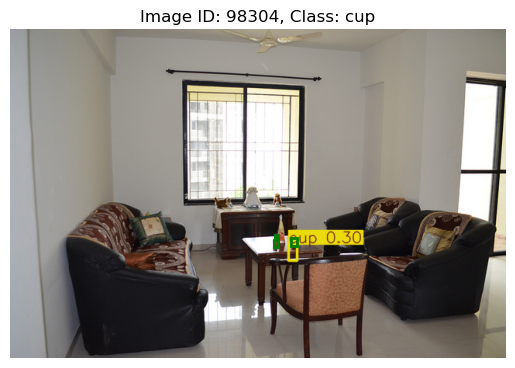

Processing 9579 images for cup:   0%|          | 1/9579 [00:00<55:42,  2.87image/s]

xyxy: tensor([[186.9553, 164.9337, 239.0873, 229.3447]])
xywh: tensor([[213.0213, 197.1392,  52.1321,  64.4109]])
Conf: tensor([[0.6140]])
Cls: tensor([[41.]])
Full class probs: tensor([6.3969e-07, 2.5498e-07, 2.2952e-05, 1.6830e-07, 1.3590e-07, 3.0223e-07, 1.0251e-07, 6.2954e-06, 1.5356e-07, 2.1600e-05, 2.5191e-06, 2.2152e-06, 9.0208e-06, 4.1574e-08, 2.3807e-06, 6.1254e-07, 2.3215e-07, 3.3502e-08, 8.0479e-09, 3.2105e-07, 1.4532e-07, 8.6608e-08, 8.0908e-08, 3.5786e-09, 4.0642e-07, 1.8837e-07,
        1.4866e-05, 8.2943e-08, 2.3950e-06, 5.6671e-06, 7.0370e-08, 4.9220e-06, 4.1541e-06, 8.6066e-07, 1.2137e-08, 3.9786e-07, 9.3548e-06, 8.2831e-08, 4.5224e-08, 2.1092e-03, 5.1170e-04, 6.1401e-01, 2.7602e-06, 9.6917e-06, 2.7437e-05, 2.1870e-03, 8.9152e-08, 4.0333e-06, 1.2908e-05, 8.2095e-06, 1.3940e-07, 7.3046e-07,
        3.2779e-06, 1.5844e-07, 4.6689e-06, 1.7588e-05, 1.1046e-05, 1.1424e-07, 1.1405e-05, 5.8059e-09, 2.1111e-06, 8.6503e-06, 1.1105e-06, 1.7028e-05, 3.8316e-05, 7.7108e-06, 6.5030

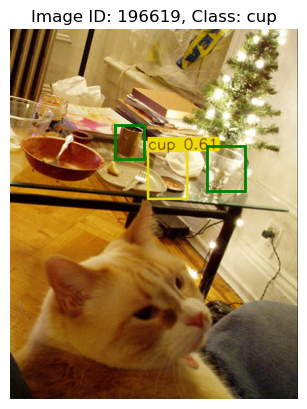

Processing 9579 images for cup:   0%|          | 2/9579 [00:00<52:26,  3.04image/s]

xyxy: tensor([], size=(0, 4))
xywh: tensor([], size=(0, 4))
Conf: tensor([], size=(0, 1))
Cls: tensor([], size=(0, 1))


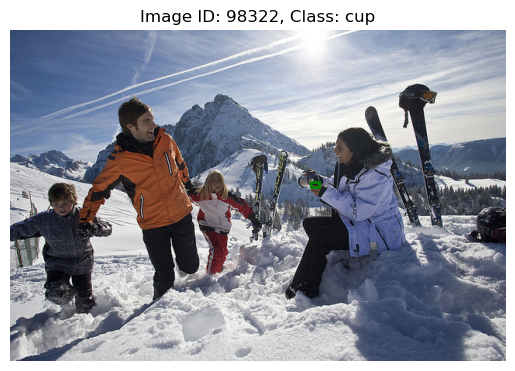

Processing 9579 images for cup:   0%|          | 3/9579 [00:01<1:01:29,  2.60image/s]

xyxy: tensor([], size=(0, 4))
xywh: tensor([], size=(0, 4))
Conf: tensor([], size=(0, 1))
Cls: tensor([], size=(0, 1))


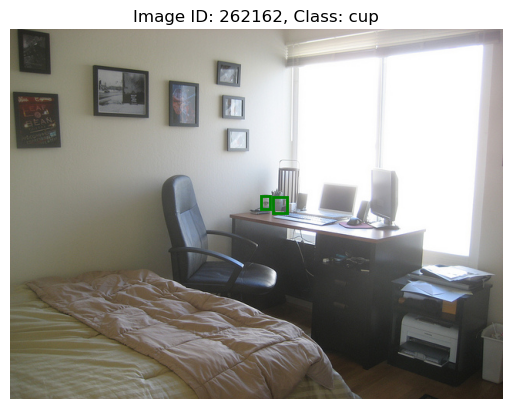

Processing 9579 images for cup:   0%|          | 4/9579 [00:01<59:17,  2.69image/s]  

xyxy: tensor([], size=(0, 4))
xywh: tensor([], size=(0, 4))
Conf: tensor([], size=(0, 1))
Cls: tensor([], size=(0, 1))


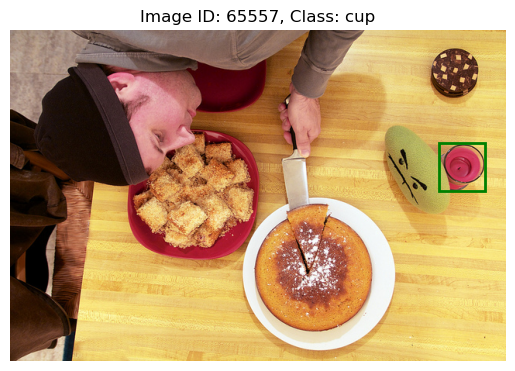

Processing 9579 images for cup:   0%|          | 5/9579 [00:01<1:05:16,  2.44image/s]

xyxy: tensor([[491.7911, 390.1784, 528.7885, 434.2756],
        [481.5886, 370.9991, 511.2797, 402.1055],
        [455.1492, 389.0309, 486.9053, 425.4676],
        [550.8213, 365.4174, 598.1395, 456.2350],
        [425.1136, 391.2573, 459.1156, 428.3413]])
xywh: tensor([[510.2898, 412.2270,  36.9974,  44.0972],
        [496.4341, 386.5523,  29.6911,  31.1064],
        [471.0273, 407.2492,  31.7562,  36.4368],
        [574.4804, 410.8262,  47.3182,  90.8176],
        [442.1146, 409.7993,  34.0020,  37.0840]])
Conf: tensor([[0.7345],
        [0.5319],
        [0.5078],
        [0.5028],
        [0.3250]])
Cls: tensor([[41.],
        [41.],
        [41.],
        [41.],
        [41.]])
Full class probs: tensor([2.7170e-10, 1.5086e-08, 3.4288e-08, 3.8037e-07, 1.0740e-09, 8.8519e-08, 2.8567e-08, 4.7159e-07, 2.7890e-07, 2.9317e-08, 4.6850e-07, 4.7666e-08, 1.1234e-06, 1.6777e-07, 3.7057e-08, 1.6037e-08, 3.1441e-08, 3.8984e-10, 9.1578e-10, 3.4450e-09, 4.7874e-11, 6.2947e-09, 6.0236e-10, 8.6249

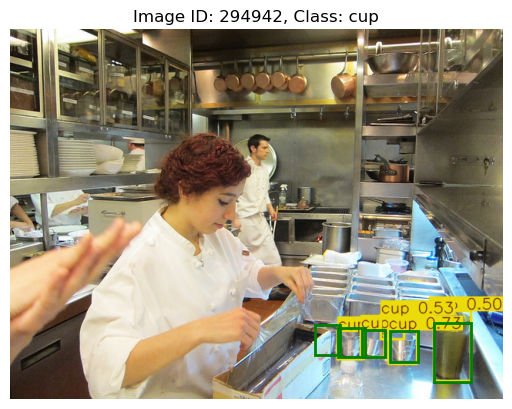

Processing 9579 images for cup:   0%|          | 6/9579 [00:02<59:33,  2.68image/s]  

xyxy: tensor([[ 80.4100, 602.5055, 127.0297, 639.7618],
        [323.7177, 481.6929, 367.2740, 577.1249],
        [324.4610, 481.7676, 364.9193, 529.7860]])
xywh: tensor([[103.7199, 621.1337,  46.6197,  37.2563],
        [345.4958, 529.4089,  43.5563,  95.4320],
        [344.6901, 505.7768,  40.4583,  48.0184]])
Conf: tensor([[0.5180],
        [0.4739],
        [0.3210]])
Cls: tensor([[41.],
        [41.],
        [41.]])
Full class probs: tensor([5.7370e-06, 2.4766e-07, 1.8964e-06, 5.1894e-06, 9.6402e-07, 7.2930e-07, 8.7225e-08, 1.1693e-05, 7.2646e-06, 4.6165e-06, 9.0701e-06, 1.8559e-06, 3.1211e-06, 8.3772e-06, 1.4320e-06, 1.1218e-06, 6.4080e-07, 1.0420e-08, 2.5416e-08, 2.8610e-08, 1.6164e-09, 1.2018e-07, 2.7951e-09, 7.7441e-10, 8.5899e-07, 4.1423e-07,
        5.2069e-05, 1.4183e-06, 1.0454e-05, 2.0957e-06, 1.2009e-07, 5.4486e-07, 3.6937e-05, 8.8696e-07, 7.0099e-08, 2.5233e-08, 1.0224e-05, 4.2099e-07, 1.0836e-07, 2.1433e-02, 1.7081e-03, 5.1798e-01, 2.0864e-05, 3.1005e-05, 5.1115e-05, 

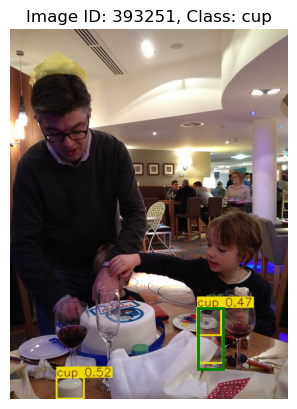

Processing 9579 images for cup:   0%|          | 7/9579 [00:02<1:02:04,  2.57image/s]

xyxy: tensor([[378.5450,  58.5864, 551.5488, 221.9327]])
xywh: tensor([[465.0469, 140.2595, 173.0038, 163.3463]])
Conf: tensor([[0.9086]])
Cls: tensor([[41.]])
Full class probs: tensor([1.5330e-05, 1.2442e-06, 9.6110e-07, 2.3647e-07, 9.6793e-06, 1.1004e-06, 7.9800e-08, 2.8771e-07, 1.1207e-08, 2.7147e-05, 5.6937e-07, 2.0684e-05, 6.7491e-06, 1.9199e-08, 2.3379e-07, 4.2536e-07, 8.1288e-08, 4.6327e-05, 1.6721e-07, 7.8593e-06, 5.6531e-06, 5.5135e-09, 2.3339e-07, 1.0749e-08, 1.7843e-06, 4.4815e-07,
        1.2913e-05, 7.1854e-08, 1.4514e-07, 2.7545e-06, 9.0794e-08, 7.6899e-08, 1.2493e-05, 6.3437e-07, 2.1853e-07, 5.2283e-06, 1.1551e-06, 5.1078e-06, 1.3058e-06, 5.7057e-04, 1.7210e-03, 9.0857e-01, 7.5925e-06, 5.3981e-06, 4.2545e-05, 4.6843e-03, 9.9211e-06, 1.5197e-05, 3.1684e-06, 1.5507e-05, 3.2813e-08, 2.1684e-07,
        2.6104e-06, 3.8566e-08, 1.1955e-05, 1.2123e-05, 2.8708e-05, 1.1381e-07, 8.6356e-06, 1.4630e-09, 2.9255e-06, 6.5565e-05, 4.4438e-06, 1.1673e-05, 9.8068e-05, 3.0922e-06, 1.0605

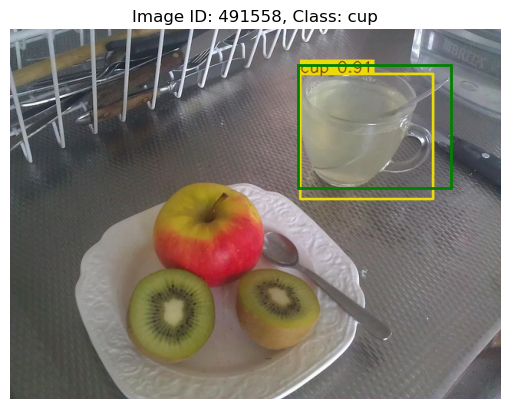

Processing 9579 images for cup:   0%|          | 8/9579 [00:02<58:52,  2.71image/s]  

xyxy: tensor([], size=(0, 4))
xywh: tensor([], size=(0, 4))
Conf: tensor([], size=(0, 1))
Cls: tensor([], size=(0, 1))


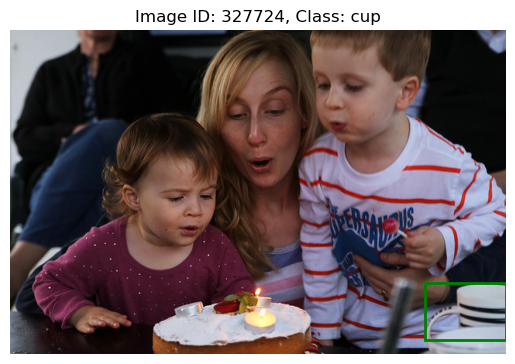

Processing 9579 images for cup:   0%|          | 9/9579 [00:03<1:02:00,  2.57image/s]

xyxy: tensor([[135.9874, 456.4034, 171.4908, 479.6176],
        [155.0601, 375.4280, 186.9404, 408.7091],
        [261.0694, 371.0685, 282.3621, 421.5007],
        [281.1839, 370.8320, 301.4159, 413.3306],
        [230.8836, 363.6324, 254.2693, 399.6206],
        [472.2913, 334.2571, 491.1281, 378.0845]])
xywh: tensor([[153.7391, 468.0105,  35.5034,  23.2142],
        [171.0002, 392.0685,  31.8803,  33.2811],
        [271.7158, 396.2846,  21.2927,  50.4322],
        [291.2999, 392.0813,  20.2320,  42.4987],
        [242.5764, 381.6265,  23.3856,  35.9882],
        [481.7097, 356.1708,  18.8368,  43.8274]])
Conf: tensor([[0.5516],
        [0.5430],
        [0.4435],
        [0.3997],
        [0.3958],
        [0.3707]])
Cls: tensor([[41.],
        [41.],
        [41.],
        [41.],
        [41.],
        [41.]])
Full class probs: tensor([5.0866e-06, 1.2096e-06, 2.9320e-07, 1.5755e-06, 4.5801e-09, 2.7121e-07, 6.8687e-09, 1.4025e-07, 5.4976e-07, 6.8321e-09, 9.7069e-08, 1.4697e-06, 2.114

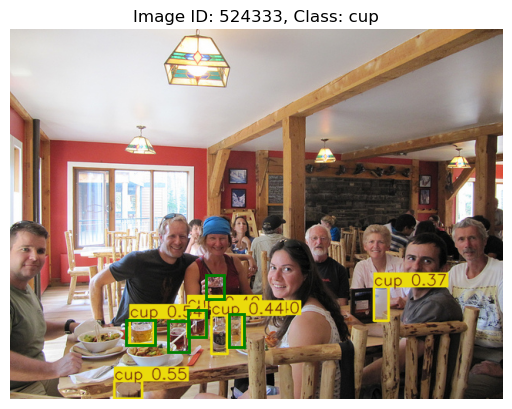

Processing 9579 images for cup:   0%|          | 10/9579 [00:03<59:02,  2.70image/s] 

xyxy: tensor([[514.8519, 354.2397, 603.8690, 479.5440],
        [493.1869, 271.2573, 544.4174, 355.5442],
        [106.1578, 215.5045, 150.5446, 294.2816],
        [549.7715, 297.4201, 605.0879, 336.4906],
        [548.3279, 328.2577, 609.7769, 375.4514]])
xywh: tensor([[559.3604, 416.8918,  89.0171, 125.3043],
        [518.8021, 313.4007,  51.2304,  84.2869],
        [128.3512, 254.8931,  44.3868,  78.7770],
        [577.4297, 316.9554,  55.3164,  39.0705],
        [579.0524, 351.8546,  61.4490,  47.1937]])
Conf: tensor([[0.8857],
        [0.8793],
        [0.7201],
        [0.5655],
        [0.4718]])
Cls: tensor([[41.],
        [41.],
        [41.],
        [41.],
        [41.]])
Full class probs: tensor([2.7601e-06, 1.3994e-07, 2.8150e-05, 8.3114e-08, 2.8342e-08, 3.7886e-07, 6.5573e-08, 1.3290e-05, 9.0950e-09, 1.4664e-06, 4.7611e-06, 3.9628e-07, 8.1820e-06, 2.5801e-08, 3.0673e-07, 1.3312e-06, 1.3925e-06, 1.8286e-08, 2.1446e-08, 8.8639e-07, 5.3994e-07, 7.2799e-08, 1.4590e-07, 2.6895

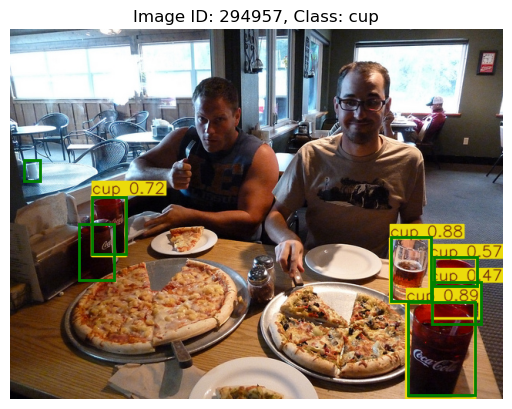

Processing 9579 images for cup:   0%|          | 11/9579 [00:04<1:04:09,  2.49image/s]

xyxy: tensor([[210.3699, 244.9556, 270.6949, 327.7516],
        [420.6469, 234.8031, 461.6628, 311.4189],
        [195.9251, 346.3254, 234.1118, 389.2864],
        [280.4808, 381.0579, 345.6409, 470.7639]])
xywh: tensor([[240.5324, 286.3536,  60.3250,  82.7960],
        [441.1548, 273.1110,  41.0158,  76.6158],
        [215.0184, 367.8059,  38.1867,  42.9611],
        [313.0609, 425.9109,  65.1600,  89.7059]])
Conf: tensor([[0.8181],
        [0.6703],
        [0.5035],
        [0.4724]])
Cls: tensor([[41.],
        [41.],
        [41.],
        [41.]])
Full class probs: tensor([1.0546e-05, 4.5827e-07, 5.2485e-06, 4.8718e-07, 2.1128e-07, 2.4185e-07, 1.1443e-07, 2.9211e-06, 6.3229e-08, 1.0994e-05, 2.6713e-06, 3.0093e-06, 3.8481e-06, 1.8111e-08, 6.0156e-06, 6.0082e-06, 2.5373e-06, 2.7864e-07, 2.8970e-08, 1.3760e-06, 8.3464e-07, 4.0893e-07, 1.1133e-07, 1.0512e-08, 1.9110e-06, 7.0657e-07,
        6.4625e-05, 1.0534e-06, 6.7396e-06, 1.0856e-05, 3.0489e-07, 1.2736e-05, 6.1879e-06, 3.9453e-06,

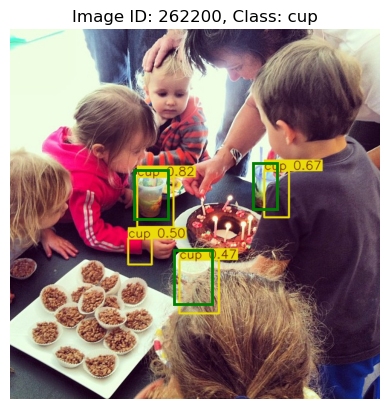

Processing 9579 images for cup:   0%|          | 12/9579 [00:04<59:42,  2.67image/s]  

xyxy: tensor([], size=(0, 4))
xywh: tensor([], size=(0, 4))
Conf: tensor([], size=(0, 1))
Cls: tensor([], size=(0, 1))


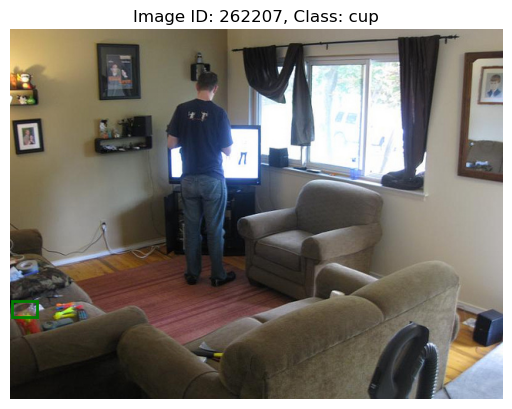

Processing 9579 images for cup:   0%|          | 13/9579 [00:04<1:01:34,  2.59image/s]

xyxy: tensor([], size=(0, 4))
xywh: tensor([], size=(0, 4))
Conf: tensor([], size=(0, 1))
Cls: tensor([], size=(0, 1))


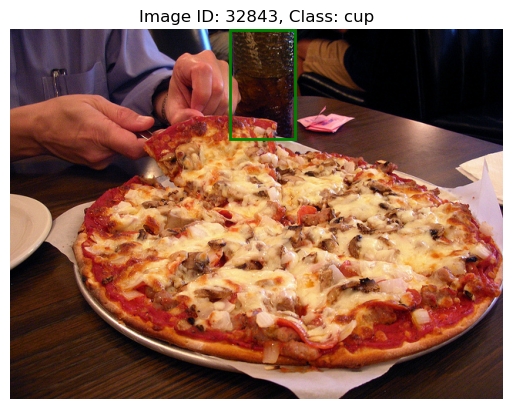

Processing 9579 images for cup:   0%|          | 14/9579 [00:05<56:16,  2.83image/s]  

xyxy: tensor([[345.4465, 151.1694, 632.7101, 327.4594]])
xywh: tensor([[489.0783, 239.3144, 287.2635, 176.2900]])
Conf: tensor([[0.9185]])
Cls: tensor([[41.]])
Full class probs: tensor([1.2324e-06, 8.2235e-06, 4.1626e-07, 3.4707e-08, 1.9734e-06, 2.1890e-07, 1.6101e-08, 4.2235e-08, 6.1326e-09, 1.1459e-06, 1.7122e-07, 2.2830e-05, 1.5764e-07, 1.4037e-07, 4.6856e-08, 6.9655e-07, 1.0871e-08, 1.4063e-04, 4.4267e-07, 5.2556e-07, 8.5178e-06, 1.6384e-09, 6.5323e-06, 4.1686e-10, 1.1801e-06, 3.4513e-07,
        3.4553e-05, 4.8562e-09, 6.1982e-07, 1.7729e-06, 5.6855e-08, 2.7652e-09, 3.4662e-06, 4.3451e-08, 5.9279e-08, 1.8031e-06, 2.6648e-07, 6.5058e-06, 2.3702e-06, 3.3433e-05, 1.1323e-05, 9.1850e-01, 4.5587e-06, 1.9151e-06, 1.8957e-06, 1.1872e-02, 5.8921e-05, 4.8472e-06, 1.5755e-06, 1.9410e-05, 1.1036e-08, 1.8485e-08,
        2.5362e-07, 7.4165e-09, 8.2127e-07, 9.2676e-06, 3.2783e-05, 1.0266e-06, 2.9543e-05, 2.2321e-09, 8.5207e-06, 4.1982e-05, 1.9939e-06, 3.0679e-05, 9.8814e-05, 6.6710e-07, 4.1610

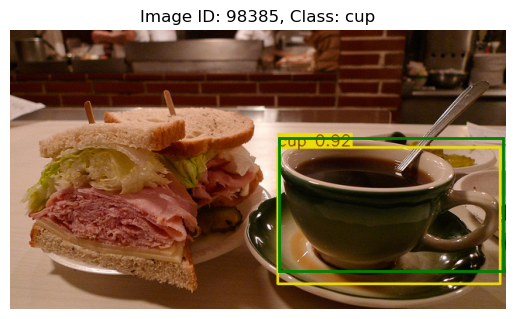

Processing 9579 images for cup:   0%|          | 15/9579 [00:05<57:49,  2.76image/s]

xyxy: tensor([], size=(0, 4))
xywh: tensor([], size=(0, 4))
Conf: tensor([], size=(0, 1))
Cls: tensor([], size=(0, 1))


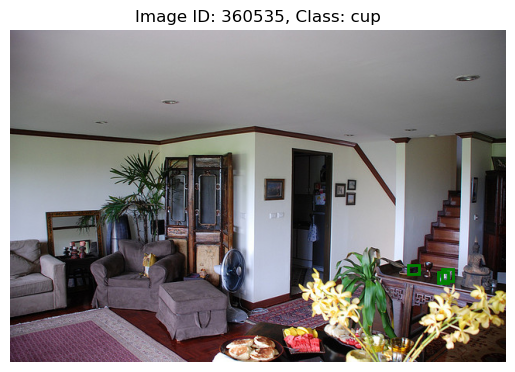

Processing 9579 images for cup:   0%|          | 16/9579 [00:06<1:02:35,  2.55image/s]

xyxy: tensor([[195.1639, 242.4245, 444.8194, 479.6382]])
xywh: tensor([[319.9917, 361.0313, 249.6555, 237.2137]])
Conf: tensor([[0.8537]])
Cls: tensor([[41.]])
Full class probs: tensor([1.8439e-05, 1.6716e-07, 4.7508e-07, 7.1171e-08, 1.9818e-07, 4.2933e-07, 1.0671e-08, 1.6786e-07, 9.5195e-09, 1.9414e-05, 7.3164e-07, 1.8126e-05, 3.4995e-05, 4.0890e-08, 4.0912e-07, 1.0529e-06, 4.2421e-07, 2.5087e-05, 6.3877e-07, 2.4774e-06, 4.4189e-06, 2.8420e-08, 1.6665e-07, 5.2085e-09, 9.2505e-06, 1.0230e-07,
        4.0577e-05, 3.1546e-07, 1.2301e-06, 1.0071e-05, 1.6420e-08, 1.0174e-07, 3.7533e-05, 9.6963e-08, 1.1896e-07, 5.3488e-06, 3.0772e-07, 1.7352e-06, 1.1293e-06, 1.3498e-03, 7.3243e-04, 8.5372e-01, 4.2604e-06, 7.4767e-06, 7.7790e-05, 1.2034e-02, 1.9957e-05, 3.1099e-05, 1.7407e-05, 2.4015e-05, 7.3861e-07, 1.4090e-06,
        4.4493e-06, 9.3909e-08, 7.8949e-05, 1.2831e-05, 1.8226e-04, 2.4763e-06, 5.4673e-05, 1.6695e-09, 6.6807e-07, 7.6279e-05, 7.5086e-06, 2.6095e-05, 1.8507e-04, 1.2786e-05, 4.3830

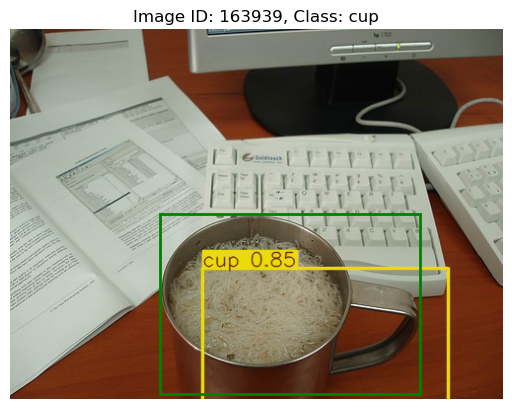

Processing 9579 images for cup:   0%|          | 17/9579 [00:06<1:04:00,  2.49image/s]

xyxy: tensor([], size=(0, 4))
xywh: tensor([], size=(0, 4))
Conf: tensor([], size=(0, 1))
Cls: tensor([], size=(0, 1))


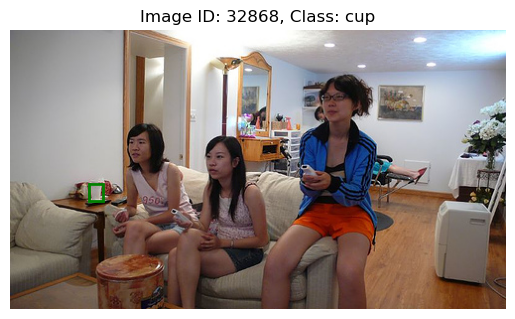

Processing 9579 images for cup:   0%|          | 18/9579 [00:06<56:04,  2.84image/s]  

xyxy: tensor([], size=(0, 4))
xywh: tensor([], size=(0, 4))
Conf: tensor([], size=(0, 1))
Cls: tensor([], size=(0, 1))


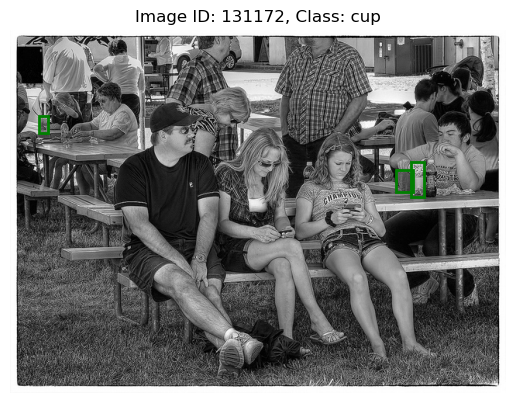

Processing 9579 images for cup:   0%|          | 19/9579 [00:07<58:24,  2.73image/s]

xyxy: tensor([[199.6419, 264.8157, 457.4183, 561.5923]])
xywh: tensor([[328.5301, 413.2040, 257.7764, 296.7766]])
Conf: tensor([[0.4593]])
Cls: tensor([[41.]])
Full class probs: tensor([5.5480e-05, 7.9994e-06, 2.0770e-06, 6.9319e-07, 1.1122e-06, 7.1939e-08, 4.8867e-09, 1.2532e-09, 1.4780e-06, 1.2575e-06, 1.8368e-08, 1.7425e-06, 2.0781e-07, 1.2893e-08, 1.6893e-05, 3.3463e-05, 5.1030e-07, 9.4379e-05, 5.4705e-07, 2.4878e-07, 4.9739e-07, 1.8940e-08, 6.2706e-07, 1.9213e-09, 1.0168e-05, 6.1773e-07,
        1.9502e-04, 1.5038e-07, 1.6163e-06, 7.3622e-05, 3.8548e-07, 2.2335e-07, 5.0768e-04, 2.2910e-07, 8.6277e-07, 7.9613e-06, 1.0903e-06, 3.4409e-05, 7.4646e-05, 5.5118e-03, 1.0871e-03, 4.5934e-01, 3.5582e-04, 1.9391e-05, 3.2598e-04, 7.7619e-02, 8.2328e-05, 3.3533e-04, 6.9257e-07, 1.2695e-05, 7.5149e-07, 1.7046e-07,
        1.8408e-06, 1.9208e-07, 4.8579e-06, 7.7818e-06, 4.6661e-05, 1.7024e-06, 4.8336e-05, 4.3469e-08, 1.8226e-07, 5.7335e-05, 7.3556e-06, 7.4075e-05, 4.5313e-02, 2.6819e-05, 1.6153

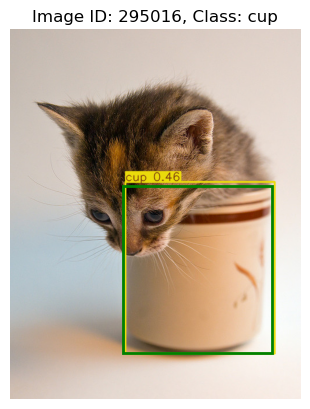

Processing 9579 images for cup:   0%|          | 20/9579 [00:07<59:19,  2.69image/s]

xyxy: tensor([], size=(0, 4))
xywh: tensor([], size=(0, 4))
Conf: tensor([], size=(0, 1))
Cls: tensor([], size=(0, 1))


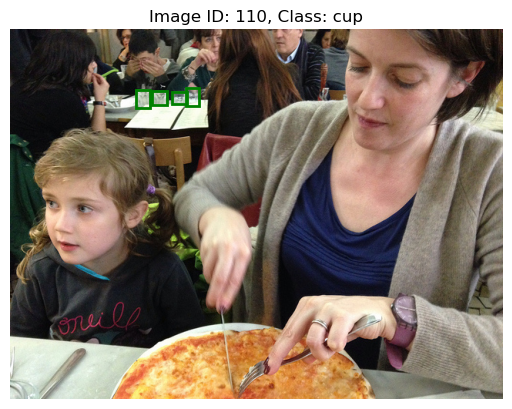

Processing 9579 images for cup:   0%|          | 20/9579 [00:07<1:02:37,  2.54image/s]


In [ ]:
# === Score storage: {class_name: {bin_index: [scores]}} ===
score_vectors_by_class_bin = {
    class_name: {i: [] for i in range(len(out_bins_per_class[class_name]) - 1)}
    for class_name in out_bins_per_class
}
allofit = []

# Loop through every class_id
for i in range(3, num_classes):

    # Get all image IDs for this class (from both splits)
    img_ids = []
    for split, coco_obj in cocos.items():
        img_ids += coco_obj.getImgIds(catIds=[coco_ids[i]])
        allofit += coco_obj.getImgIds(catIds=[coco_ids[i]])
    
    k = 0
    # Loop through each image ID
    for img_id in tqdm(img_ids, desc=f"Processing {len(img_ids)} images for {classes_names[i]}", unit="image"):
        
        # Find the split for the current image ID
        split, any_coco = find_split_for_image(img_id)
        
        # Load the image 
        img_data = any_coco.imgs[img_id]
        img_path = os.path.join(os.getenv("COCO_DATA"), split, img_data["file_name"])
        img = io.imread(img_path)

        # Use predict() explicitly
        results = yolo_model.predict(source=img, device='cuda:0', conf=0.3, iou=0.5, verbose=False, classes = [yolo_ids[i]], max_det=100)

        # Visualize
        print("xyxy:", results[0].boxes.xyxy)
        print("xywh:", results[0].boxes.xywh)
        print("Conf:", results[0].boxes.conf)
        print("Cls:", results[0].boxes.cls)
        for box in results[0].boxes:
            print("Full class probs:", box.data[0][6 : 6 + yolo_model.model.nc])

        # Plot predicted boxes
        plt.imshow(results[0].plot())
        plt.axis('off')

        # Plot ground truth boxes from COCO using COCO API
        ann_ids = any_coco.getAnnIds(imgIds=img_id, catIds=[coco_ids[i]], iscrowd=None)
        anns = any_coco.loadAnns(ann_ids)
        for ann in anns:
            bbox = ann["bbox"]
            x, y, w, h = bbox
            plt.gca().add_patch(plt.Rectangle((x, y), w, h, fill=False, edgecolor="green", linewidth=2))
        plt.title(f"Image ID: {img_id}, Class: {classes_names[i]}")
        plt.show()

        # Compute IoU between predicted and ground truth boxes



        # Increment
        k +=1

        if k > 20:
            break
    
    break


# TODO: GET CONFIDENCE SCORES, COMPARE GROUND WITH PREDICTED USING IOU, ASSIGN CONFIDENCE SCORES TO BINS

# For every predicted bbox, check the ground truth bbox with highest IoU --> use prob vector for that prediction (scale is computed from prediction)

# Predict every class for every image! The predicted bounding boxes, independent of class, are used to compute the IoU with the ground truth bounding boxes. The predicted bounding boxes are then used to assign the confidence scores to the bins.
# Problem: how much IoU? Maximum supremum? 

In [ ]:
import torch

if torch.cuda.is_available():
    print("GPU Name:", torch.cuda.get_device_name(0))
    print("Memory Allocated:", round(torch.cuda.memory_allocated(0)/1024**2, 2), "MB")
    print("Memory Reserved:", round(torch.cuda.memory_reserved(0)/1024**2, 2), "MB")
    print("Total Memory:", round(torch.cuda.get_device_properties(0).total_memory/1024**2, 2), "MB")
else:
    print("No CUDA-compatible GPU detected.")

In [ ]:
# Function to print RAM usage
def print_ram_usage():
    import psutil
    ram = psutil.virtual_memory()
    print(f"RAM usage: {ram.percent}% used, {ram.available / (1024 ** 3):.2f} GB available")
    print(f"RAM total: {ram.total / (1024 ** 3):.2f} GB total")
    print(f"RAM used: {ram.used / (1024 ** 3):.2f} GB used")
    print(f"RAM free: {ram.free / (1024 ** 3):.2f} GB free")

In [ ]:
# eng = matlab.engine.start_matlab()
# eng.addpath(os.getenv("FASTFIT_TOOLBOX"), nargout=0)

# eng.quit()